# 1. Configuração e Importação

Antes de começarmos a analisar e treinar nosso modelo, precisamos importar o dataset, e verificar se foi importado corretamente.

# Importação do Dataset

Ha métodos diferentes para importar o dataset, se estiver rodando VS Code, ou Colab. Rode a célula abaixo de acordo com o que você estiver usando.

## Colab (via URL)

In [8]:
print("\n-> 1. Baixando e Extraindo o Dataset")

# Limpeza Previa
!rm -f casting_512x512.zip

# Baixa o dataset usando a URL de download direto correta
!wget -q --show-progress -O casting_512x512.zip https://github.com/dnkamo/SC_TEC-M2_S07-Mini-Projeto-CNN-OpenCV-Pecas/raw/main/dataset/casting_512x512.zip

# Extrai o conteúdo
!unzip -q -o casting_512x512.zip
print("Download e extração concluídos!")


-> 1. Baixando e Extraindo o Dataset
casting_512x512.zip 100%[===================>]  30.69M   176MB/s    in 0.2s    
Download e extração concluídos!


## Arquivo Local

In [ ]:
print("\n-> 1. Extraindo o Dataset Localmente")

import os
import zipfile

# Definindo os caminhos corretos
nome_zip = "../dataset/casting_512x512.zip"
pasta_extraida = "casting_512x512"

# Verificando se o arquivo zip existe antes de tentar extrair
if os.path.exists(nome_zip):

    if not os.path.exists(pasta_extraida):

        print("Extraindo as imagens...")
        with zipfile.ZipFile(nome_zip, 'r') as zip_ref:

            zip_ref.extractall(pasta_extraida)

        print("Extração concluída!")
    else:
        print("O Dataset já está extraído!")
else:
    print(f"ERRO: O arquivo '{nome_zip}' não foi encontrado para extração.")

## Teste de Verificação

In [9]:
# ========================================================
# Verificando se o dataset está extraído e pronto para usar

import os

pasta_extraida = 'casting_512x512'

if os.path.exists(pasta_extraida):
    print(f"Verificando a pasta: {pasta_extraida}")
    for root, dirs, files in os.walk(pasta_extraida):
        level = root.replace(pasta_extraida, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f"{indent}{os.path.basename(root)}/ - {len(files)} arquivos")
else:
    print(f"ERRO: A pasta '{pasta_extraida}' não foi encontrada. Verifique se a extração ocorreu corretamente.")

Verificando a pasta: casting_512x512
casting_512x512/ - 0 arquivos
    def_front/ - 781 arquivos
    ok_front/ - 519 arquivos


# 2. Analise Exploratória com OpenCV

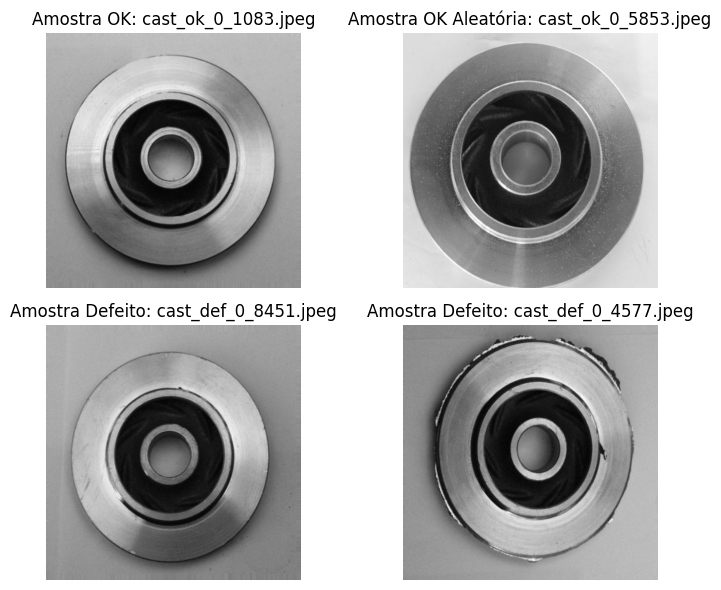

In [44]:
# =====================================
# 1. PEGANDO IMAGENS DE AMOSTRA
# =====================================

import cv2
import matplotlib.pyplot as plt
import os
import random

# Caminhos das pastas
dir_ok = 'casting_512x512/ok_front'
dir_def = 'casting_512x512/def_front'

# Para deixar as imagens consistentes, podemos pegar as primeiras
# imagens de cada pasta, ou podemos pegar uma imagem qualquer
# por meio de escolha aleatória

# METODO 1
# Pegando as primeiras imagens:
# ------------------------------------

# Listando os arquivos (pegando os primeiros 1 de cada)
img_ok_name = os.listdir(dir_ok)[0]
img_def_name = os.listdir(dir_def)[0]

# METODO 2
# Pegando imagens aleatórias:
# ------------------------------------

img_ok_name_random = os.listdir(dir_ok)
img_def_name_random = os.listdir(dir_def)

img_ok_choice_random = random.choice(img_ok_name_random)
img_def_choice_random = random.choice(img_def_name_random)

# Lendo as imagens com OpenCV
# ------------------------------------
# Primeiras
img_ok = cv2.imread(os.path.join(dir_ok, img_ok_name))
img_def = cv2.imread(os.path.join(dir_def, img_def_name))

# Aleatório
img_ok_random = cv2.imread(os.path.join(dir_ok, img_ok_choice_random))
img_def_random = cv2.imread(os.path.join(dir_def, img_def_choice_random))

# ------------------------------------
# Convertendo de BGR (OpenCV) para RGB (Matplotlib)
img_ok_rgb = cv2.cvtColor(img_ok, cv2.COLOR_BGR2RGB)
img_def_rgb = cv2.cvtColor(img_def, cv2.COLOR_BGR2RGB)

img_ok_rgb_random = cv2.cvtColor(img_ok_random, cv2.COLOR_BGR2RGB)
img_def_rgb_random = cv2.cvtColor(img_def_random, cv2.COLOR_BGR2RGB)

# Exibindo as amostras
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes[0, 0].imshow(img_ok_rgb)
axes[0, 0].set_title(f'Amostra OK: {img_ok_name}')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_ok_rgb_random)
axes[0, 1].set_title(f'Amostra OK Aleatória: {img_ok_choice_random}')
axes[0, 1].axis('off')

axes[1, 0].imshow(img_def_rgb)
axes[1, 0].set_title(f'Amostra Defeito: {img_def_name}')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_def_rgb_random)
axes[1, 1].set_title(f'Amostra Defeito: {img_def_choice_random}')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# =====================================
# 2. APLICANDO FILTROS NAS IMAGENS
# =====================================

# Com nossas amostras selecionadas, podemos aplicar
# conversão em escala de cinza, assim como filtros
# de suavização